In [12]:
import numpy as np
import matplotlib.pyplot as plt
from bf_regression import *
import emukit.test_functions
from emukit.multi_fidelity.convert_lists_to_array import convert_x_list_to_array
from numpy.linalg import norm

high_fidelity = lambda x: emukit.test_functions.forrester.forrester(norm(x, axis=1)[:,None])
low_fidelity = lambda x: emukit.test_functions.forrester.forrester_low(norm(x, axis=1)[:,None])

NUM_LF = 30
NUM_HF = 6

# Sample data (longitude, latitude, value)
# Primary variable data (sparse)
X_LF = np.random.rand(NUM_LF, 2)
X_HF = X_LF[:NUM_HF]

Y_LF = low_fidelity(X_LF)
Y_HF = high_fidelity(X_HF)

model = bf_linear_gp_regression(X_LF, Y_LF, X_HF, Y_HF)

# Grid points where predictions are needed
gridx = np.arange(0.0, 1.0, 0.1)
gridy = np.arange(0.0, 1.0, 0.1)
Xx, Xy = np.meshgrid(gridx, gridy)
X = np.hstack((Xx.reshape(-1,1), Xy.reshape(-1,1)))

# Predict at grid points
X_plot = convert_x_list_to_array([X, X])
X_plot_LF = X_plot[:len(X)]
X_plot_HF = X_plot[len(X):]
Y_plot_LF_mean, Y_plot_LF_var = model.predict(X_plot_LF)
Y_plot_HF_mean, Y_plot_HF_var = model.predict(X_plot_HF)


 /opt/anaconda3/lib/python3.7/site-packages/paramz/transformations.py:111: RuntimeWarning:divide by zero encountered in log


Optimization restart 1/5, f = 99.21552753376683
Optimization restart 2/5, f = 99.2155275796846
Optimization restart 3/5, f = 99.21552753068289
Optimization restart 4/5, f = 99.21552753148691
Optimization restart 5/5, f = 99.21552753388438


In [13]:
# Evaluate actual LF and HF functions at grid points
Y_plot_LF = low_fidelity(X)
Y_plot_HF = high_fidelity(X)

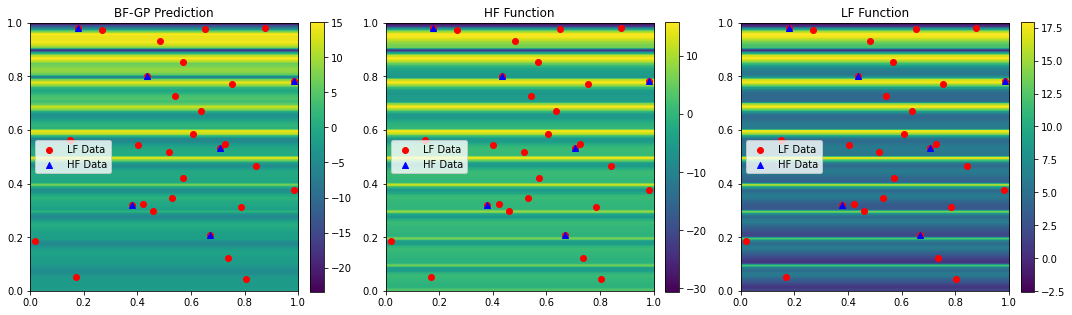

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

# First Subplot - Heatmap
cs1 = axs[0].imshow(Y_plot_HF_mean, origin='lower', extent=(0.0, 1.0, 0.0, 1.0), cmap='viridis')
fig.colorbar(cs1, ax=axs[0], fraction=0.046, pad=0.04)
axs[0].scatter(X_LF[:, 0], X_LF[:, 1], marker='o', c='r', label='LF Data')
axs[0].scatter(X_HF[:, 0], X_HF[:, 1], marker='^', c='b', label='HF Data')
axs[0].set_title('BF-GP Prediction')
axs[0].legend()

# Second Subplot - HF Data Scatter
cs2 = axs[1].imshow(Y_plot_HF, origin='lower', extent=(0.0, 1.0, 0.0, 1.0), cmap='viridis')
fig.colorbar(cs2, ax=axs[1], fraction=0.046, pad=0.04)
axs[1].scatter(X_LF[:, 0], X_LF[:, 1], marker='o', c='r', label='LF Data')
axs[1].scatter(X_HF[:, 0], X_HF[:, 1], marker='^', c='b', label='HF Data')
axs[1].set_title('HF Function')
axs[1].legend()

# Third Subplot - LF Data Scatter
cs3 = axs[2].imshow(Y_plot_LF, origin='lower', extent=(0.0, 1.0, 0.0, 1.0), cmap='viridis')
fig.colorbar(cs3, ax=axs[2], fraction=0.046, pad=0.04)
axs[2].scatter(X_LF[:, 0], X_LF[:, 1], marker='o', c='r', label='LF Data')
axs[2].scatter(X_HF[:, 0], X_HF[:, 1], marker='^', c='b', label='HF Data')
axs[2].set_title('LF Function')
axs[2].legend()

plt.tight_layout()
plt.show()